## # WebSight_70k — статистический анализ датасета

> ⚠ **Источник переключён на WebSight v0.2 (`HuggingFaceM4/WebSight`, Tailwind).**
> Числа в выходах ниже посчитаны на старом v0.1-срезе (`WebSight_70k`, plain CSS) и
> **устарели** — перезапустить ноутбук на v0.2 (p99 токенов вырастет: Tailwind-разметка
> многословнее). `IMAGE_TOKEN_BUDGET=0` — `max_length` не учитывает визуальные токены.

Ноутбук считает по датасету `mrm8488/WebSight_70k` метрики, аналогичные анализу WebCode2M.

Метрики:
1. Количество примеров
2. Количество языков (если присутствует поле lang)
3. Средний размер HTML
4. Среднее количество DOM-узлов
5. Размер скриншота
6. Среднее количество CSS правил
7. Среднее количество уникальных доменов


## 1. Установка зависимостей

In [13]:
%pip install -q datasets lxml pandas matplotlib tqdm huggingface_hub


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Импорты и конфигурация

In [14]:
import os
import re
import logging
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from tqdm.auto import tqdm

HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

import datasets
from datasets import load_dataset

logging.getLogger("httpx").setLevel(logging.WARNING)

DATASET = "HuggingFaceM4/WebSight"   # v0.2 (~2M, Tailwind) — тот же источник, что и таргеты конвертера
# отладочный лёгкий срез: "mrm8488/WebSight_70k" (v0.1, plain CSS — НЕ Tailwind)
SPLIT = "train"
SAMPLE_SIZE = 5000

print(f"datasets: {datasets.__version__}")
print(f"Датасет: {DATASET}, выборка: {SAMPLE_SIZE}")

# --- Токенная длина кода (метрика 3, на замену символьной) ---
from token_len import count_tokens, recommend_max_length
from transformers import AutoTokenizer
# Точный id — когда SFT зафиксирует модель. Счётчики токенов у Qwen 2.5/3/3.5
# практически совпадают, поэтому это валидный прокси для оценки бюджета max_length.
TOKENIZER_ID = "Qwen/Qwen3-VL-8B-Instruct"
IMAGE_TOKEN_BUDGET = 0   # бюджет визуальных токенов — заложить после согласования разрешения
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)
print("tokenizer:", TOKENIZER_ID)


datasets: 5.0.0
Датасет: HuggingFaceM4/WebSight, выборка: 5000
tokenizer: Qwen/Qwen3-VL-8B-Instruct


## 3. Метрика 1 — количество примеров

In [15]:
from huggingface_hub import HfApi

# Точное число примеров через Hub API — без скачивания всего датасета (как в webui.ipynb).
# У WebSight несколько конфигов (v0.1/v0.2) → card_data["dataset_info"] это СПИСОК;
# берём конфиг с наибольшим train (это v0.2, дефолтный для load_dataset).
_di = HfApi().dataset_info(DATASET).card_data["dataset_info"]
_configs = _di if isinstance(_di, list) else [_di]
def _train_n(cfg):
    return next((s["num_examples"] for s in cfg["splits"] if s["name"] == SPLIT), 0)
_best = max(_configs, key=_train_n)
TOTAL_EXAMPLES = _train_n(_best)

print(f"[Метрика 1] Количество примеров в датасете ({SPLIT}): {TOTAL_EXAMPLES:,}")

[Метрика 1] Количество примеров в датасете (train): 1,922,671


## 4. Загрузка стрим-датасета

In [16]:
dataset = load_dataset(DATASET, streaming=True)
dataset

sample = next(iter(dataset[SPLIT].take(1)))
print(sample.keys())

dict_keys(['image', 'text', 'llm_generated_idea'])


## 5. Функции-хелперы

In [17]:
def count_dom_nodes(tree):
    # //text() включает whitespace-узлы (переносы строк между тегами) — фильтруем пустые,
    # иначе DOM-count завышается форматированием кода.
    return len(tree.xpath(".//*")) + len(tree.xpath("//text()[normalize-space()]"))

# Декларация property:value. Исключаем ложные срабатывания на url(http://...) и data:
# (лишние двоеточия в значениях) — берём первое двоеточие как разделитель property/value.
_DECL_RE = re.compile(r"[A-Za-z-]+\s*:[^;{}]+")

def _count_declarations(css_body):
    return sum(1 for _ in _DECL_RE.finditer(css_body))

def count_css_declarations(tree):
    total = 0
    for style_attr in tree.xpath("//*/@style"):
        total += _count_declarations(style_attr)

    for style_text in tree.xpath("//style//text()"):
        for block in re.findall(r"\{([^{}]*)\}", style_text):
            total += _count_declarations(block)

    return total

def count_unique_domains(tree):
    domains = set()

    for url in tree.xpath("//@src | //@href | //@data-src"):
        url = (url or "").strip()

        if not url or url.startswith(
            ("#", "mailto:", "tel:", "javascript:", "data:")
        ):
            continue

        parse_target = "http:" + url if url.startswith("//") else url

        netloc = urlparse(parse_target).netloc.lower()

        if netloc:
            domains.add(netloc)

    return len(domains)

## 6. Главный цикл по выборке

In [18]:
records = []

for row in tqdm(dataset[SPLIT].take(SAMPLE_SIZE),
                total=SAMPLE_SIZE,
                desc="Обработка"):

    text = (
        row.get("text")
        or row.get("html")
        or row.get("code")
        or ""
    )

    img = row.get("image")
    img_w, img_h = (
        img.size if img is not None else (None, None)
    )

    lang = row.get("lang", "unknown")

    rec = {
        "html_chars": len(text),
        "html_tokens": count_tokens(text, tokenizer),
        "html_bytes": len(text.encode("utf-8")),
        "img_w": img_w,
        "img_h": img_h,
        "dom_nodes": None,
        "css_decls": None,
        "n_domains": None,
        "lang": str(lang).lower(),
        "parse_ok": False,
    }

    try:
        tree = lxml_html.fromstring(text)

        rec["dom_nodes"] = count_dom_nodes(tree)
        rec["css_decls"] = count_css_declarations(tree)
        rec["n_domains"] = count_unique_domains(tree)
        rec["parse_ok"] = True

    except Exception:
        pass

    records.append(rec)

print(
    f"Собрано записей: {len(records)}, "
    f"распарсено успешно: "
    f"{sum(r['parse_ok'] for r in records)}"
)

Обработка: 100%|██████████| 5000/5000 [00:50<00:00, 98.58it/s] 

Собрано записей: 5000, распарсено успешно: 5000


## 7. DataFrame с признаками

In [19]:
df = pd.DataFrame(records)

print(
    f"Размер списка признаков в памяти: "
    f"{df.memory_usage(deep=True).sum()/1024**2:.2f} МБ"
)

df.head()

Размер списка признаков в памяти: 0.38 МБ


,html_chars,html_tokens,html_bytes,img_w,img_h,dom_nodes,css_decls,n_domains,lang,parse_ok
0,1274,359,1274,2560,1440,18,0,2,unknown,True
1,2135,530,2135,2560,1440,28,0,1,unknown,True
2,2253,524,2253,2560,1440,27,0,1,unknown,True
3,2624,682,2624,2560,1440,45,0,2,unknown,True
4,1684,436,1684,2560,2008,20,1,2,unknown,True


## 8. Агрегированные метрики

In [20]:
ok = df[df["parse_ok"]]

agg = pd.DataFrame({
    "mean": [
        ok["html_tokens"].mean(),
        ok["html_chars"].mean(),
        ok["html_bytes"].mean(),
        ok["dom_nodes"].mean(),
        ok["css_decls"].mean(),
        ok["n_domains"].mean(),
        ok["img_h"].mean(),
    ],
    "median": [
        ok["html_tokens"].median(),
        ok["html_chars"].median(),
        ok["html_bytes"].median(),
        ok["dom_nodes"].median(),
        ok["css_decls"].median(),
        ok["n_domains"].median(),
        ok["img_h"].median(),
    ],
}, index=[
    "Код (токены)",
    "HTML символов",
    "HTML байт",
    "DOM-узлы",
    "CSS декларации",
    "Уникальные домены",
    "Высота скриншота, px"
])

agg.round(1)

,mean,median
Код (токены),457.7,445.0
HTML символов,1690.5,1636.0
HTML байт,1690.6,1636.0
DOM-узлы,27.0,26.0
CSS декларации,0.2,0.0
Уникальные домены,1.5,2.0
"Высота скриншота, px",1621.4,1440.0


## 9. Метрика 2 — количество языков

In [21]:
if "lang" in df.columns:
    lang_counts = df["lang"].value_counts()
    n_langs = df.loc[df["lang"] != "unknown", "lang"].nunique()

    print(f"Уникальных языков: {n_langs}")
    display(lang_counts.head(15))
else:
    print("Поле lang отсутствует")

Уникальных языков: 0


lang
unknown    5000
Name: count, dtype: int64

## 10. Гистограммы распределений

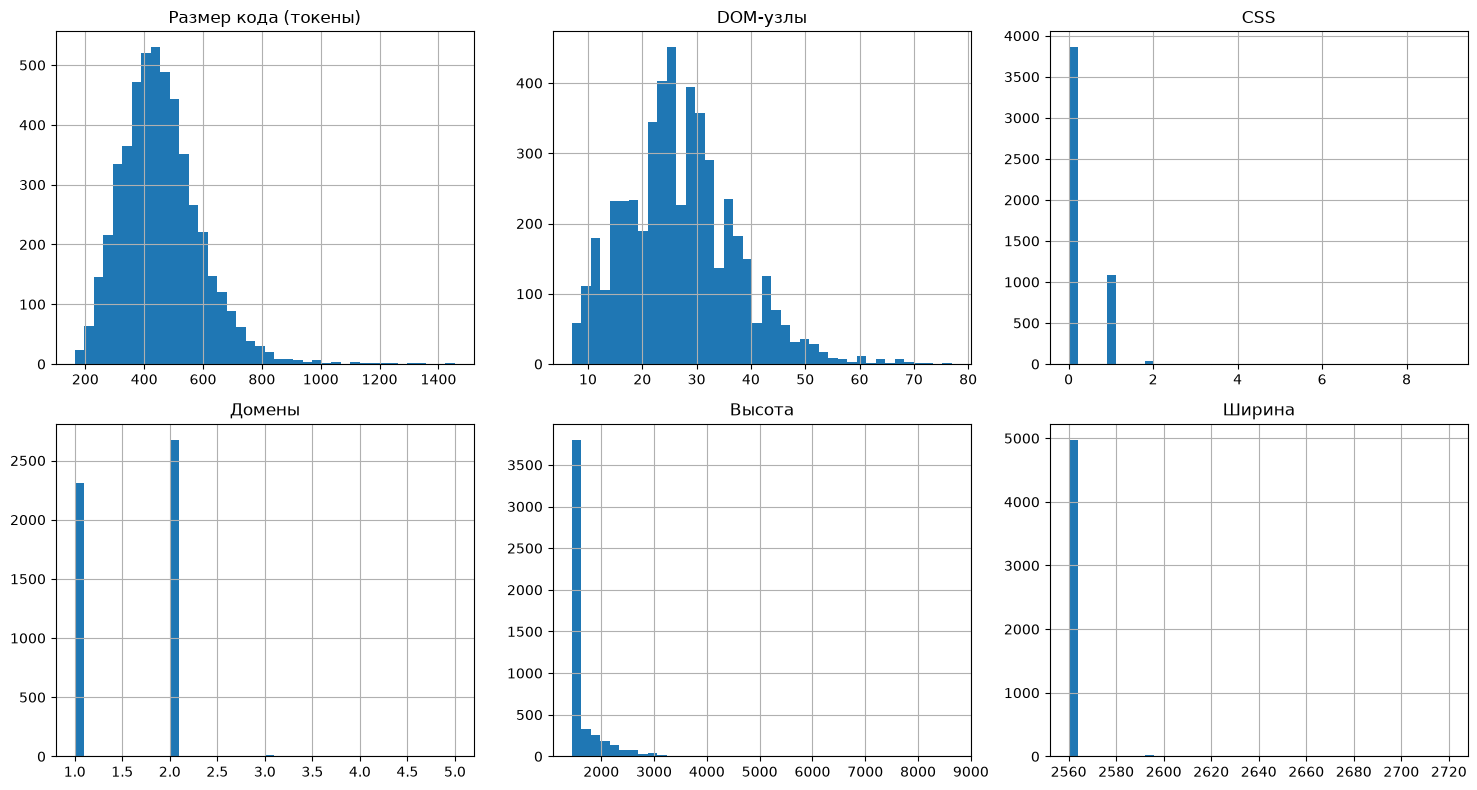

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ok["html_tokens"].hist(ax=axes[0,0], bins=40)
axes[0,0].set_title("Размер кода (токены)")

ok["dom_nodes"].hist(ax=axes[0,1], bins=40)
axes[0,1].set_title("DOM-узлы")

ok["css_decls"].hist(ax=axes[0,2], bins=40)
axes[0,2].set_title("CSS")

ok["n_domains"].hist(ax=axes[1,0], bins=40)
axes[1,0].set_title("Домены")

ok["img_h"].hist(ax=axes[1,1], bins=40)
axes[1,1].set_title("Высота")

ok["img_w"].hist(ax=axes[1,2], bins=40)
axes[1,2].set_title("Ширина")

plt.tight_layout()
plt.show()

## 11. Итоговая сводка

In [23]:
def fmt(x):
    return f"{x:,.1f}" if x is not None else "n/a"

summary = pd.DataFrame([
    ("Количество примеров", f"{TOTAL_EXAMPLES:,}"),
    ("Средний размер кода (токены, Qwen)", fmt(ok["html_tokens"].mean())),
    ("p99 токенов (ориентир для max_length)", fmt(ok["html_tokens"].quantile(0.99))),
    ("Среднее число DOM-узлов", fmt(ok["dom_nodes"].mean())),
    ("Среднее число CSS правил", fmt(ok["css_decls"].mean())),
    ("Среднее число доменов", fmt(ok["n_domains"].mean()))
], columns=["Метрика", "Значение"])

summary

,Метрика,Значение
0,Количество примеров,"1,922,671"
1,"Средний размер кода (токены, Qwen)",457.7
2,p99 токенов (ориентир для max_length),851.0
3,Среднее число DOM-узлов,27.0
4,Среднее число CSS правил,0.2
5,Среднее число доменов,1.5


## Рекомендуемый max_length (токены)

In [24]:
# Ориентир max_length (контракт SFT): p99 длины кода в токенах, округл. вверх до 64,
# + бюджет визуальных токенов. Та же логика, что compute_max_length в token_len.py.
_tok_col = "code_tokens" if "code_tokens" in ok.columns else "html_tokens"
_rec = recommend_max_length(ok[_tok_col].tolist(), quantile=0.99, round_to=64,
                            image_token_budget=IMAGE_TOKEN_BUDGET)
print(f"Токены кода: median={ok[_tok_col].median():.0f}, "
      f"p99={ok[_tok_col].quantile(0.99):.0f}, max={ok[_tok_col].max():.0f}")
print(f"Рекомендуемый max_length (p99 → округл. 64, +img {IMAGE_TOKEN_BUDGET}): {_rec}")

Токены кода: median=445, p99=851, max=1456
Рекомендуемый max_length (p99 → округл. 64, +img 0): 896
